# Tez Yılı Tahmininde Kollektif Öğrenme

Bu çalışmada, 2001–2025 yılları arasındaki Türkçe akademik tezlerin başlık ve özet metinlerinden yararlanarak tez yılını tahmin etmeyi amaçlıyorum. 

Bu amaçla:

- Hugging Face üzerinde yer alan **"umutertugrul/turkish-academic-theses-dataset"** veri kümesinin yerel bir kopyası olan `tezler.parquet` dosyasını kullanacağım.
- **2001–2025** yılları arasındaki her yıl için **500 tez** seçeceğim.
- Her yıl için:
  - **250 tez eğitim (train)**,
  - **250 tez test (test)**
  olacak şekilde dengeli bir ayrım yapacağım.
- Tezlerin **Türkçe başlık (`title_tr`)** ve **Türkçe özet (`abstract_tr`)** alanlarından,
  **`ytu-ce-cosmos/turkish-e5-large`** modeli ile metin temsilleri (embedding) elde edeceğim.


## 1. Veri Kümesinin Yerel Parquet Dosyasından Yüklenmesi

Bu adımda:

- Çalışma klasöründe bulunan `tezler.parquet` dosyasını `pandas` ile okuyorum.
- Veri kümesinin boyutunu ve ilk birkaç satırını inceleyerek,
  sütun yapısını doğruluyorum.

Önemli sütunlar:

- `title_tr`   Tezin Türkçe başlığı
- `abstract_tr`  Tezin Türkçe özeti
- `year`  Tezin yayın yılı


In [1]:
import pandas as pd

# Parquet dosyasını okuma
df = pd.read_parquet("tezler.parquet")

print("Veri kümesinin boyutu:", df.shape)
df.head()


Veri kümesinin boyutu: (648974, 16)


,tez_no,pdf_url,title_tr,title_en,author,advisor,location,subject,index,status,degree,language,year,pages,abstract_tr,abstract_en
0,51304,https://tez.yok.gov.tr/UlusalTezMerkezi/TezGos...,Bolu ilköğretim okullarında yönetici öğretmen ...,None,KAYA YILDIZ,PROF.DR. KEMAL GÜÇLÜOL,Abant İzzet Baysal Üniversitesi / Sosyal Bilim...,Eğitim ve Öğretim = Education and Training,Bolu = Bolu ; Yöneticiler = Managers ; Öğretme...,Onaylandı,Yüksek Lisans,Türkçe,1996,204,ÖZET BOLU İLKÖ?RETİM OKULLARINDA YÖNETİCİ -Ö?R...,ABSTRACT THE COMMUNICATION OF PRINCIPALS AND T...
1,51311,https://tez.yok.gov.tr/UlusalTezMerkezi/TezGos...,İlköğretim amaçlarının gerçekleştirilmesinde i...,None,NURİ AKGÜN,Y.DOÇ.DR. M. DURDU KARSU,Abant İzzet Baysal Üniversitesi / Sosyal Bilim...,Eğitim ve Öğretim = Education and Training,Öğretmen yetiştirme = Teacher training ; İlköğ...,Onaylandı,Yüksek Lisans,Türkçe,1996,202,ÖZET İLKÖ?RETİMİN AMAÇLARININ GERÇEKLEŞTİRİLME...,ABSTRACT ACTUAL AND IDEAL PHYSICAL AND HUMAN R...
2,51310,https://tez.yok.gov.tr/UlusalTezMerkezi/TezGos...,Anadolu güzel sanatlar liseleri müzik bölümler...,None,NESRİN KALYONCU,PROF.DR. KADİR KARKIN,Abant İzzet Baysal Üniversitesi / Sosyal Bilim...,Müzik = Music,Eğitim = Education ; Güzel sanatlar liseleri =...,Onaylandı,Yüksek Lisans,Türkçe,1996,83,ÖZET ANADOLU GÜZEL SANATLAR LİSELERİ MÜZİK BÖL...,ZUSAMMENFASSUNG DER ZIEL VERWIRKLICHUNGSGRAD D...
3,51306,https://tez.yok.gov.tr/UlusalTezMerkezi/TezGos...,İlköğretim müfettişlerinin mesleksel gelişmele...,None,BAHRİ AYDIN,PROF.DR. ALİ GÜLER,Abant İzzet Baysal Üniversitesi / Sosyal Bilim...,Eğitim ve Öğretim = Education and Training,Beklentiler = Expectations ; Denetçiler = Cont...,Onaylandı,Yüksek Lisans,Türkçe,1996,59,ÖZET İLKÖ?RETİM MÜFETTİŞLERİNİN MESLEKSEL GELİ...,ABSTRACT VOCATIONAL DEVELOPMENT OF PRIMARY EDU...
4,51303,https://tez.yok.gov.tr/UlusalTezMerkezi/TezGos...,İlköğretim müfettişlerinin eğitim-öğretim faal...,None,YUSUF CERİT,PROF.DR. MÜRÜVVET BİLEN,Abant İzzet Baysal Üniversitesi / Sosyal Bilim...,Eğitim ve Öğretim = Education and Training,Denetçiler = Controller ; Eğitim = Education ;...,Onaylandı,Yüksek Lisans,Türkçe,1996,170,ÖZET İLKÖ?RETİM MÜFETTİŞLERİNİN E?İTİM - Ö?RET...,ABSTRACT PRIMARY EDUCATION SUPERVISORS' ACTIVI...


## 2. 2001–2025 Yıllarının Seçilmesi ve Eksik Metinlerin Temizlenmesi

Ödev kapsamında yalnızca **2001–2025** yılları arasındaki tezlerle çalışmam gerekiyor. 
Ayrıca embedding üretimi için hem başlık hem de özet metinlerinin dolu olması önemli.

Bu nedenle:

1. `year` sütununu kullanarak yalnızca 2001–2025 aralığındaki tezleri seçiyorum.
2. `title_tr` veya `abstract_tr` alanı eksik olan tezleri veri kümesinden çıkarıyorum.


In [2]:
# Yıl aralığı filtresi
df = df[df["year"].between(2001, 2025)]

# Başlık veya özet eksik olan kayıtları çıkar
df = df.dropna(subset=["title_tr", "abstract_tr"])

print("Filtrelenmiş veri boyutu:", df.shape)
df[["year", "title_tr", "abstract_tr"]].head()


Filtrelenmiş veri boyutu: (626022, 16)


,year,title_tr,abstract_tr
49,2001,Çağdaş ve demokratik eğitimde teftiş /,ÖZET ÇAĞDAŞ VE DEMOKRATİK EĞİTİMDE TEFTİŞ ÖZDE...
50,2001,İnsan kaynakları yönetimi ilkelerine ilişkin B...,ÖZET İNSAN KAYNAKLARI YÖNETİMİ İLKELERİNE İLİŞ...
51,2001,Gençlik ve Spor Genel Müdürlüğü`nün (GSGM) mer...,"Bu çalışmanın amacı, Gençlik ve Spor Genel Müd..."
52,2001,Örgüt kültürü ve iş tatmini ilişkisi /,ÖZET ÖRGÜT KÜLTÜRÜ ve İŞ TATMİNİ İLİŞKİSİ EREN...
53,2001,İnsan sesinde fizyolojik değişim ve gelişim (m...,ÖZET İNSAN SESİNDE FİZYOLOJİK DEĞİŞİM VE GELİŞ...


## 3. Her Yıl İçin 500 Tezin Rastgele Seçilmesi

Ödevde, 2001–2025 yıllarının her biri için **500 tez** seçmem isteniyor. 
Bu adımda:

- 2001’den 2025’e kadar her yıl için,
- O yıla ait tezlerden **rastgele 500 örnek** seçiyorum.
- Tüm yıllardan seçilen bu örnekleri birleştirerek dengeli bir veri kümesi oluşturuyorum.

Seçim işlemi rastgelelik içerdiği için, sonuçların tekrar üretilebilir olması adına
`random_state=42` kullanıyorum.


In [3]:
years = range(2001, 2024+1)
samples_per_year = 500

balanced_parts = []

for y in years:
    df_y = df[df["year"] == y]
    count_y = len(df_y)
    
    print(f"Yıl {y}: mevcut tez sayısı = {count_y}")
    
    df_y_sampled = df_y.sample(n=samples_per_year, random_state=42)
    balanced_parts.append(df_y_sampled)

df_balanced = pd.concat(balanced_parts).reset_index(drop=True)

print("\nDengeli veri kümesinin boyutu:", df_balanced.shape)
df_balanced["year"].value_counts().sort_index()


Yıl 2001: mevcut tez sayısı = 2756
Yıl 2002: mevcut tez sayısı = 3372
Yıl 2003: mevcut tez sayısı = 3566
Yıl 2004: mevcut tez sayısı = 6064
Yıl 2005: mevcut tez sayısı = 7192
Yıl 2006: mevcut tez sayısı = 15818
Yıl 2007: mevcut tez sayısı = 16767
Yıl 2008: mevcut tez sayısı = 16703
Yıl 2009: mevcut tez sayısı = 18582
Yıl 2010: mevcut tez sayısı = 24247
Yıl 2011: mevcut tez sayısı = 21774
Yıl 2012: mevcut tez sayısı = 19660
Yıl 2013: mevcut tez sayısı = 21360
Yıl 2014: mevcut tez sayısı = 23466
Yıl 2015: mevcut tez sayısı = 25432
Yıl 2016: mevcut tez sayısı = 26128
Yıl 2017: mevcut tez sayısı = 29665
Yıl 2018: mevcut tez sayısı = 35904
Yıl 2019: mevcut tez sayısı = 64832
Yıl 2020: mevcut tez sayısı = 34713
Yıl 2021: mevcut tez sayısı = 42896
Yıl 2022: mevcut tez sayısı = 53065
Yıl 2023: mevcut tez sayısı = 54690
Yıl 2024: mevcut tez sayısı = 57370

Dengeli veri kümesinin boyutu: (12000, 16)


year
2001    500
2002    500
2003    500
2004    500
2005    500
2006    500
2007    500
2008    500
2009    500
2010    500
2011    500
2012    500
2013    500
2014    500
2015    500
2016    500
2017    500
2018    500
2019    500
2020    500
2021    500
2022    500
2023    500
2024    500
Name: count, dtype: int64

## 4. Yıl Bazında 250 Eğitim ve 250 Test Örneği Ayrımı

Her yıl için seçilen 500 tezi:

- **250 tez eğitim kümesine (train)**,
- **250 tez test kümesine (test)**

olarak ayırıyorum. Bunu yaparken:

- Önce ilgili yılın verisini karıştırıyor (shuffle),
- İlk 250 kaydı `train`,
- Sonraki 250 kaydı `test` olarak alıyorum.

Bu sayede hem eğitim hem test veri kümeleri yıl bazında dengeli oluyor.


In [4]:
train_parts = []
test_parts = []

for y in years:
    df_y = df_balanced[df_balanced["year"] == y].sample(frac=1, random_state=42)
    
    train_y = df_y.iloc[:250]
    test_y  = df_y.iloc[250:500]
    
    train_parts.append(train_y)
    test_parts.append(test_y)

train_df = pd.concat(train_parts).reset_index(drop=True)
test_df  = pd.concat(test_parts).reset_index(drop=True)

print("Train boyutu:", train_df.shape)
print("Test boyutu :", test_df.shape)

print("\nTrain yıl dağılımı:")
print(train_df["year"].value_counts().sort_index())

print("\nTest yıl dağılımı:")
print(test_df["year"].value_counts().sort_index())


Train boyutu: (6000, 16)
Test boyutu : (6000, 16)

Train yıl dağılımı:
year
2001    250
2002    250
2003    250
2004    250
2005    250
2006    250
2007    250
2008    250
2009    250
2010    250
2011    250
2012    250
2013    250
2014    250
2015    250
2016    250
2017    250
2018    250
2019    250
2020    250
2021    250
2022    250
2023    250
2024    250
Name: count, dtype: int64

Test yıl dağılımı:
year
2001    250
2002    250
2003    250
2004    250
2005    250
2006    250
2007    250
2008    250
2009    250
2010    250
2011    250
2012    250
2013    250
2014    250
2015    250
2016    250
2017    250
2018    250
2019    250
2020    250
2021    250
2022    250
2023    250
2024    250
Name: count, dtype: int64


## 5. Metin Temsillerinin Üretilmesi

Bu bölümde Türkçe tez başlıkları ve özetlerinden metin temsilleri (embedding) üretmek için  
`ytu-ce-cosmos/turkish-e5-large` modeli kullanılmıştır.

Model üç farklı temsil oluşturmak için kullanılmıştır:

1. **Başlık temsili:** Sadece `title_tr` alanından embedding  
2. **Özet temsili:** Sadece `abstract_tr` alanından embedding  
3. **Birleşik temsil:** Başlık + özet metinlerinin birleştirilmiş hali  


In [5]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from tqdm.auto import tqdm

MODEL_NAME = "ytu-ce-cosmos/turkish-e5-large"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

device


C:\Users\emirk\anaconda3\envs\fdcurv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cuda'

### 5.1 Embedding Üretim Fonksiyonunun Tanımlanması

Bu fonksiyon, verilen metin listesini `ytu-ce-cosmos/turkish-e5-large` modeli ile işleyerek
her metin için sabit boyutlu bir embedding vektörü üretir. Hesaplama verimliliği için 
metinler batch halinde işlenmektedir.


In [6]:
import numpy as np
from tqdm.auto import tqdm

def get_embeddings(text_list, batch_size=32):
    
    all_embeddings = []

    for i in tqdm(range(0, len(text_list), batch_size), desc="Embedding üretiliyor"):
        batch_texts = text_list[i:i+batch_size]

        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=256
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        batch_emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
        all_embeddings.append(batch_emb)

    return np.vstack(all_embeddings)


### 5.2 Başlık Embeddingleri

Bu adımda, eğitim ve test kümelerindeki `title_tr` alanını kullanarak
yalnızca tez başlıklarına dayalı metin temsilleri üretiyorum.
Bu temsil daha sonra "başlıktan yıl tahmini" modeli için kullanılacaktır.


In [7]:
# Eğitim ve test için başlık metinleri
train_titles = train_df["title_tr"].tolist()
test_titles  = test_df["title_tr"].tolist()

# Başlık embedding'leri
train_title_emb = get_embeddings(train_titles, batch_size=32)
test_title_emb  = get_embeddings(test_titles, batch_size=32)

print("Train title embedding şekli :", train_title_emb.shape)
print("Test  title embedding şekli :", test_title_emb.shape)


Embedding üretiliyor: 100%|██████████| 188/188 [00:24<00:00,  7.79it/s]

Train title embedding şekli : (6000, 1024)
Test  title embedding şekli : (6000, 1024)


### 5.3 Özet Embeddingleri

Bu adımda, `abstract_tr` alanı kullanılarak yalnızca tez özetlerinden embedding üretilmektedir.
Bu temsil, "özetten yıl tahmini" modeli için kullanılacaktır.


In [8]:
# Eğitim ve test için özet metinleri
train_abstracts = train_df["abstract_tr"].tolist()
test_abstracts  = test_df["abstract_tr"].tolist()

# Özet embedding'leri
train_abs_emb = get_embeddings(train_abstracts, batch_size=32)
test_abs_emb  = get_embeddings(test_abstracts, batch_size=32)

print("Train abstract embedding şekli :", train_abs_emb.shape)
print("Test  abstract embedding şekli :", test_abs_emb.shape)


Embedding üretiliyor: 100%|██████████| 188/188 [02:28<00:00,  1.26it/s]

Train abstract embedding şekli : (6000, 1024)
Test  abstract embedding şekli : (6000, 1024)


### 5.4 Başlık + Özet Birleşik Embedding

Bu temsilde, başlık ve özet metinleri birleştirilerek tek bir metin haline getirilmiş,
ardından bu birleşik metinden embedding üretilmiştir. Böylece model hem başlıktan
hem de özetten gelen bilgiyi aynı vektörde temsil etmektedir.


In [9]:
# Eğitim ve test için birleşik metinler (başlık + özet)
train_combined = (train_df["title_tr"] + ". " + train_df["abstract_tr"]).tolist()
test_combined  = (test_df["title_tr"]  + ". " + test_df["abstract_tr"]).tolist()

# Birleşik embedding'ler
train_comb_emb = get_embeddings(train_combined, batch_size=32)
test_comb_emb  = get_embeddings(test_combined, batch_size=32)

print("Train combined embedding şekli :", train_comb_emb.shape)
print("Test  combined embedding şekli :", test_comb_emb.shape)


Embedding üretiliyor: 100%|██████████| 188/188 [02:29<00:00,  1.26it/s]

Train combined embedding şekli : (6000, 1024)
Test  combined embedding şekli : (6000, 1024)


### 5.5 Yıl Bilgisinin Hazırlanması

Modelleme aşamasında tahmin edilmek istenen hedef değişken, tezin yayın yılıdır.
Bu nedenle eğitim ve test kümelerindeki `year` sütunu ayrı vektörler halinde çıkarılmıştır.


In [10]:
y_train = train_df["year"].values
y_test  = test_df["year"].values

print("y_train şekli:", y_train.shape)
print("y_test  şekli:", y_test.shape)


y_train şekli: (6000,)
y_test  şekli: (6000,)


### 5.6 Ara Özet

Bu aşamada aşağıdaki adımlar tamamlanmıştır:

- 2001–2025 yılları arasındaki tezler filtrelenmiş ve eksik metinler temizlenmiştir.
- Her yıl için 500 tez seçilerek dengeli bir veri kümesi oluşturulmuştur.
- Her yılın 500 tezinin 250'si eğitim, 250'si test kümesine ayrılmıştır.
- `ytu-ce-cosmos/turkish-e5-large` modeli ile:
  - Başlık temsili (`train_title_emb`, `test_title_emb`),
  - Özet temsili (`train_abs_emb`, `test_abs_emb`),
  - Başlık + özet birleşik temsili (`train_comb_emb`, `test_comb_emb`)
  üretilmiştir.
- Hedef etiketler `y_train` ve `y_test` vektörleri olarak hazırlanmıştır.

Bir sonraki bölümde, bu üç farklı temsil için Bagging, Random Subspace ve Random Forest
algoritmaları uygulanarak yıl tahmini performansları karşılaştırılacaktır.


## 6. Modelleme ve Hiperparametre Optimizasyonu

Bu bölümde, önceki aşamada elde edilen üç farklı metin temsili (başlık, özet, başlık+özet)  
üzerinde üç farklı kolektif öğrenme yönteminin performansı karşılaştırılacaktır:

1. **Bagging**
2. **Random Subspace**
3. **Random Forest**

Tüm modellerde hedef değişken tezin yılıdır (`y_train`, `y_test`).  
Her üç model için en az **iki hiperparametre** optimize edilmiştir;  

Aşağıda her algoritma için seçilen hiperparametreler detaylı olarak açıklanmaktadır.


## 6.1 Ensemble Algoritmaları İçin Seçilen Hiperparametreler

Her üç ensemble yönteminde Decision Tree tabanlı modeller kullanılmıştır.  
Bu nedenle ağaç büyüklüğünü kontrol eden `max_depth` parametresi üç model için de ortak olarak optimize edilmiştir.

### Bagging İçin Seçilen Hiperparametreler
Bagging, bootstrap örnekleme ile farklı alt modeller oluşturarak çeşitlilik sağlar.

Bu çalışmada Bagging için optimize edilen hiperparametreler:

- **`n_estimators`**  (50, 100)  
  - Eğitilecek ağaç sayısıdır. Sayı arttıkça model kararlılığı artar.
- **`max_samples`**  (0.5, 1.0)  
  - Her ağacın eğitimde kullanacağı örnek oranı. Çeşitliliği belirler.
- **`max_depth`**  (10, None)  
  - Ağaçların maksimum derinliği. Overfitting’i azaltmak için eklenmiştir.

---

### Random Subspace İçin Seçilen Hiperparametreler
Random Subspace, örnek yerine **özellik uzayında çeşitlilik** yaratır.

Optimize edilen parametreler:

- **`n_estimators`**  (50, 100)  
- **`max_features`**  (0.3, 0.5, 0.8)  
  - Her alt modelin kaç özellik göreceğini belirler.
  - Özellikle yüksek boyutlu embedding vektörlerinde çok kritiktir.
- **`max_depth`**  (10, None)

---

### Random Forest İçin Seçilen Hiperparametreler
Random Forest, hem bootstrap örnekleme hem de her düğümde rastgele özellik seçimi yapar.

Optimize edilen hiperparametreler:

- **`n_estimators`**  (100, 200)  
- **`max_features`**  ("sqrt", "log2", 0.5)  
- **`max_samples`**  (0.5, 0.8, 1.0)  
- **`max_depth`**  (10, None)

Bu parametreler birlikte kullanılarak modelin karmaşıklığı, çeşitliliği ve genelleme kapasitesi dengeli bir şekilde optimize edilmiştir.


In [11]:
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = []  # Sonuçlar burada toplanacak

def evaluate_and_log(model_name, rep_name, best_model, X_train, X_test, y_train, y_test):
    """
    En iyi modeli test setinde değerlendirir ve sonuçları global results listesine ekler.
    """
    y_pred = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n[{rep_name} - {model_name}]")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R^2  : {r2:.4f}")

    results.append({
        "Representation": rep_name,
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

def run_with_grid(model_name, estimator, param_grid, X_train, X_test, y_train, y_test, rep_name):
    """
    Verilen estimator ve parametre ızgarası için GridSearchCV uygular,
    en iyi modeli bulur ve evaluate_and_log fonksiyonunu çağırır.
    """
    grid = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=3,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        verbose=1
    )

    print(f"\n=== {rep_name} - {model_name} Grid Search Başlıyor ===")
    grid.fit(X_train, y_train)

    print("En iyi hiperparametreler:", grid.best_params_)
    best_model = grid.best_estimator_
    evaluate_and_log(model_name, rep_name, best_model, X_train, X_test, y_train, y_test)


In [12]:
# 1) Bagging 
bagging_estimator = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    random_state=42
)

param_grid_bagging = {
    "n_estimators": [50, 100],
    "max_samples": [0.5, 1.0],
    "estimator__max_depth": [10, None],
}

# 2) Random Subspace 
subspace_estimator = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    random_state=42
)

param_grid_subspace = {
    "n_estimators": [50, 100],
    "max_features": [0.3, 0.5, 0.8],
    "estimator__max_depth": [10, None],
}

# 3) Random Forest
rf_estimator = RandomForestRegressor(
    random_state=42,
    bootstrap=True
)

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_features": ["sqrt", "log2", 0.5],
    "max_samples": [0.5, 0.8, 1.0],
    "max_depth": [10, None],
}


In [13]:
# Temsil listesi: 
representations = [
    ("Title",    train_title_emb,  test_title_emb),
    ("Abstract", train_abs_emb,    test_abs_emb),
    ("Combined", train_comb_emb,   test_comb_emb),
]

for rep_name, X_tr, X_te in representations:
    print(f"\n\n########## {rep_name} Temsili ##########")

    # Bagging
    run_with_grid(
        model_name="Bagging",
        estimator=bagging_estimator,
        param_grid=param_grid_bagging,
        X_train=X_tr, X_test=X_te,
        y_train=y_train, y_test=y_test,
        rep_name=rep_name
    )

    # Random Subspace
    run_with_grid(
        model_name="Random Subspace",
        estimator=subspace_estimator,
        param_grid=param_grid_subspace,
        X_train=X_tr, X_test=X_te,
        y_train=y_train, y_test=y_test,
        rep_name=rep_name
    )

    # Random Forest
    run_with_grid(
        model_name="Random Forest",
        estimator=rf_estimator,
        param_grid=param_grid_rf,
        X_train=X_tr, X_test=X_te,
        y_train=y_train, y_test=y_test,
        rep_name=rep_name
    )




########## Title Temsili ##########

=== Title - Bagging Grid Search Başlıyor ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
En iyi hiperparametreler: {'estimator__max_depth': None, 'max_samples': 1.0, 'n_estimators': 100}

[Title - Bagging]
MAE  : 5.6833
RMSE : 6.6320
R^2  : 0.0821

=== Title - Random Subspace Grid Search Başlıyor ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits
En iyi hiperparametreler: {'estimator__max_depth': 10, 'max_features': 0.5, 'n_estimators': 100}

[Title - Random Subspace]
MAE  : 5.7004
RMSE : 6.6465
R^2  : 0.0781

=== Title - Random Forest Grid Search Başlıyor ===
Fitting 3 folds for each of 36 candidates, totalling 108 fits
En iyi hiperparametreler: {'max_depth': None, 'max_features': 0.5, 'max_samples': 0.8, 'n_estimators': 200}

[Title - Random Forest]
MAE  : 5.6831
RMSE : 6.6245
R^2  : 0.0842


########## Abstract Temsili ##########

=== Abstract - Bagging Grid Search Başlıyor ===
Fitting 3 folds for each of 8 candida

In [14]:
results_df = pd.DataFrame(results)
results_df
results_df.sort_values("MAE")


,Representation,Model,MAE,RMSE,R2
3,Abstract,Bagging,5.147714,6.100065,0.223427
5,Abstract,Random Forest,5.153005,6.090055,0.225973
4,Abstract,Random Subspace,5.167916,6.110485,0.220772
6,Combined,Bagging,5.224233,6.214464,0.194026
8,Combined,Random Forest,5.227108,6.193490,0.199458
7,Combined,Random Subspace,5.272355,6.247952,0.185317
2,Title,Random Forest,5.683112,6.624457,0.084172
0,Title,Bagging,5.683320,6.631952,0.082098
1,Title,Random Subspace,5.700363,6.646451,0.078081


### 7.1 Temsil Bazlı MAE Performans Karşılaştırma Grafikleri

Bu bölümde, üç farklı metin temsili için (sadece başlık, sadece özet, başlık+özet) 
üç modelin (Bagging, Random Subspace, Random Forest) **ortalama mutlak hata (MAE)** 
performanslarını bar grafikleri ile karşılaştırıyorum.

Her bir alt grafik:

- X ekseninde: Model adı (Bagging, Random Subspace, Random Forest)
- Y ekseninde: Test seti üzerindeki MAE değeri
- Başlıkta: Hangi temsil kullanıldığı (Title / Abstract / Combined)

Bu sayede aynı temsil altında hangi topluluk yönteminin daha iyi performans verdiğini doğrudan görselle karşılaştırmak mümkün olur.



,Representation,Model,MAE,RMSE,R2
0,Title,Bagging,5.683320,6.631952,0.082098
1,Title,Random Subspace,5.700363,6.646451,0.078081
2,Title,Random Forest,5.683112,6.624457,0.084172
3,Abstract,Bagging,5.147714,6.100065,0.223427
4,Abstract,Random Subspace,5.167916,6.110485,0.220772
5,Abstract,Random Forest,5.153005,6.090055,0.225973
6,Combined,Bagging,5.224233,6.214464,0.194026
7,Combined,Random Subspace,5.272355,6.247952,0.185317
8,Combined,Random Forest,5.227108,6.193490,0.199458


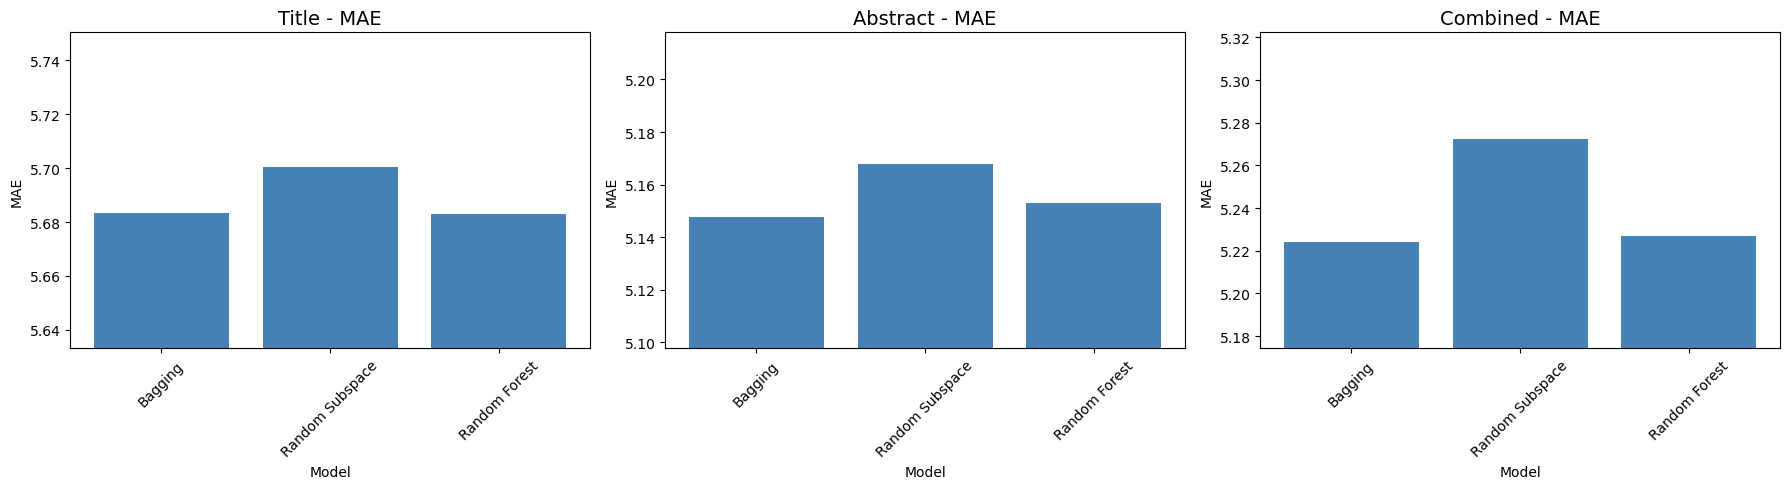

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results_df = pd.DataFrame(results)
display(results_df)

reps = ["Title", "Abstract", "Combined"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, rep in zip(axes, reps):
    subset = results_df[results_df["Representation"] == rep]

    # Bar plot
    ax.bar(subset["Model"], subset["MAE"], color="steelblue")

    ax.set_title(f"{rep} - MAE", fontsize=14)
    ax.set_xlabel("Model")
    ax.set_ylabel("MAE")

    min_val = subset["MAE"].min()
    max_val = subset["MAE"].max()
    margin = 0.05  

    ax.set_ylim(min_val - margin, max_val + margin)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("mae_by_model_and_representation.png", dpi=300, bbox_inches="tight")
plt.show()


## 7.2 Model Bazlı Performans Karşılaştırma Grafikleri

Bu bölümde model sabit tutulmuş ve üç farklı temsil (Title, Abstract, Combined)
üzerindeki performansları karşılaştırılmıştır.  

Amaç:  
- Hangi modelin hangi temsilde daha iyi sonuç verdiğini görselleştirmek  
- Temsiller arasındaki farkı daha kolay yorumlamak  

Her model için ayrı bir grafik çizilmiştir:
- Bagging: Title–Abstract–Combined 
- Random Subspace: Title–Abstract–Combined  
- Random Forest: Title–Abstract–Combined  

Bu grafikler model bazlı genelleme performanslarını değerlendirmek için önemlidir.


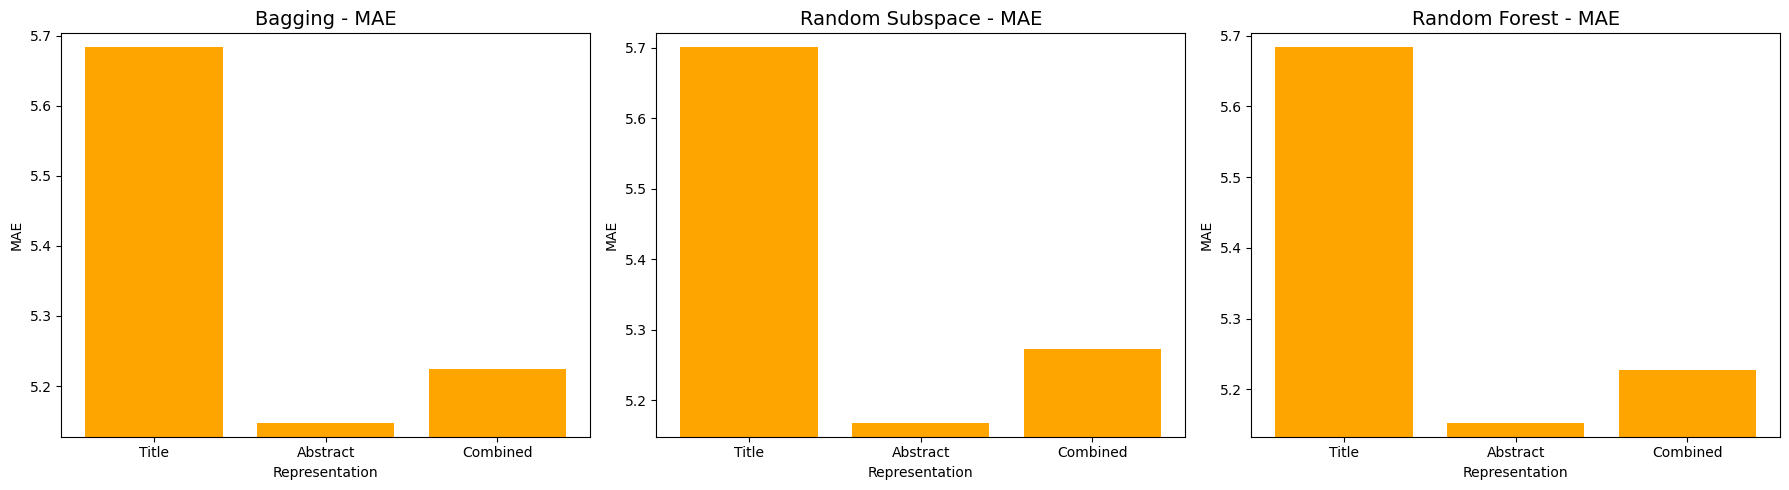

In [16]:
import matplotlib.pyplot as plt

models = ["Bagging", "Random Subspace", "Random Forest"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, model in zip(axes, models):
    subset = results_df[results_df["Model"] == model]

    ax.bar(subset["Representation"], subset["MAE"], color="orange")

    ax.set_title(f"{model} - MAE", fontsize=14)
    ax.set_xlabel("Representation")
    ax.set_ylabel("MAE")

    # Y eksenini zoomla
    min_val = subset["MAE"].min()
    max_val = subset["MAE"].max()
    margin = 0.02

    ax.set_ylim(min_val - margin, max_val + margin)

plt.tight_layout()
plt.savefig("mae_by_representation_for_each_model.png", dpi=300, bbox_inches='tight')
plt.show()


## 7.3) R² Karşılaştırma Isı Haritası (Heatmap)

Bu grafikte, satırlarda metin temsilleri (Title, Abstract, Combined),
sütunlarda ise modeller (Bagging, Random Subspace, Random Forest) olacak şekilde
R² skorlarını bir ısı haritası (heatmap) üzerinde gösteriyorum.

- Her hücredeki renk, o temsil–model ikilisinin R² değerini ifade eder.
- Hücrenin içine sayısal R² değeri de yazılarak görsel ve sayısal yorum birlikte yapılır.

Bu sayede:
- Hangi temsil–model kombinasyonunun **en yüksek R²** değerine sahip olduğu,
- Başlık mı, özet mi yoksa başlık+özet temsilinin mi daha iyi genelleme yaptığı,
- Bagging, Random Subspace ve Random Forest arasındaki farklar

tek bir görselde kolayca karşılaştırılabilir.


R² pivot tablosu:


Model,Bagging,Random Subspace,Random Forest
Representation,,,
Title,0.082098,0.078081,0.084172
Abstract,0.223427,0.220772,0.225973
Combined,0.194026,0.185317,0.199458


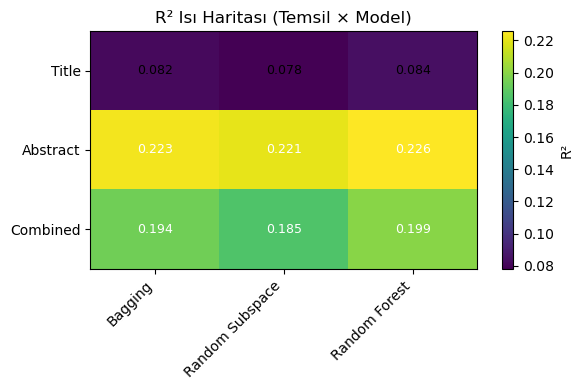

In [17]:
import numpy as np
import matplotlib.pyplot as plt

r2_pivot = results_df.pivot(
    index="Representation",
    columns="Model",
    values="R2"
)


r2_pivot = r2_pivot.loc[["Title", "Abstract", "Combined"],
                        ["Bagging", "Random Subspace", "Random Forest"]]

print("R² pivot tablosu:")
display(r2_pivot)

# Heatmap çizimi
fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(r2_pivot.values, aspect="auto")


ax.set_xticks(np.arange(r2_pivot.shape[1]))
ax.set_yticks(np.arange(r2_pivot.shape[0]))

ax.set_xticklabels(r2_pivot.columns, rotation=45, ha="right")
ax.set_yticklabels(r2_pivot.index)

ax.set_title("R² Isı Haritası (Temsil × Model)")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("R²", rotation=90)

for i in range(r2_pivot.shape[0]):
    for j in range(r2_pivot.shape[1]):
        value = r2_pivot.values[i, j]
        ax.text(
            j, i,
            f"{value:.3f}",
            ha="center",
            va="center",
            color="white" if value > r2_pivot.values.mean() else "black",
            fontsize=9
        )

plt.tight_layout()
plt.savefig("r2_heatmap_representation_model.png", dpi=300, bbox_inches='tight')
plt.show()


## 7.4 Random Forest İçin Hiperparametre Optimizasyon Grafikleri

Bu bölümde Random Forest modeli için yapılan Grid Search sonuçlarını
dört temel hiperparametre üzerinden görselleştiriyorum:

- `n_estimators`  → Ağaç sayısı
- `max_depth`     → Ağaçların maksimum derinliği
- `max_features`  → Her düğümde kullanılacak özellik oranı / sayısı
- `max_samples`   → Her ağaç için kullanılan örnek oranı

Yöntem:
- Abstract temsili üzerinde Random Forest için GridSearchCV yeniden çalıştırılmıştır.
- Her hiperparametre değeri için çapraz doğrulama ortalama MAE değeri hesaplanmıştır.
- Her hiperparametre için, MAE'nin nasıl değiştiğini gösteren çizgi grafikleri çizilmiştir.

Bu grafikler sayesinde şu sorulara cevap verilebilir:
- Ağaç sayısını artırmak (n_estimators) ne kadar fayda sağlıyor?
- Sığ ağaçlar (max_depth = 10) ile sınırsız derinlikli ağaçlar (None) arasında fark var mı?
- Özellik altkümeleri (max_features) model performansını nasıl etkiliyor?
- Örnekleme oranı (max_samples) değişince hata nasıl değişiyor?



Random Forest için Grid Search (Abstract temsili) yeniden başlatılıyor...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
GridSearch sonuç tablosu (ilk satırlar):


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_max_samples,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,mean_MAE
0,8.996065,0.075507,0.060405,0.003760,10,sqrt,0.5,100,"{'max_depth': 10, 'max_features': 'sqrt', 'max...",-11.541383,-2.059154,-11.400351,-8.333629,4.437098,28,8.333629
1,17.613711,0.242751,0.094000,0.001633,10,sqrt,0.5,200,"{'max_depth': 10, 'max_features': 'sqrt', 'max...",-11.546520,-2.030897,-11.406707,-8.328042,4.453119,26,8.328042
2,12.819272,0.193511,0.054668,0.005248,10,sqrt,0.8,100,"{'max_depth': 10, 'max_features': 'sqrt', 'max...",-11.498193,-2.075526,-11.421025,-8.331581,4.423811,27,8.331581
3,25.325437,0.439593,0.106666,0.010338,10,sqrt,0.8,200,"{'max_depth': 10, 'max_features': 'sqrt', 'max...",-11.517202,-2.037734,-11.416899,-8.323945,4.445211,23,8.323945
4,14.667521,0.206514,0.057000,0.005099,10,sqrt,1.0,100,"{'max_depth': 10, 'max_features': 'sqrt', 'max...",-11.527740,-2.046304,-11.391216,-8.321753,4.437763,20,8.321753


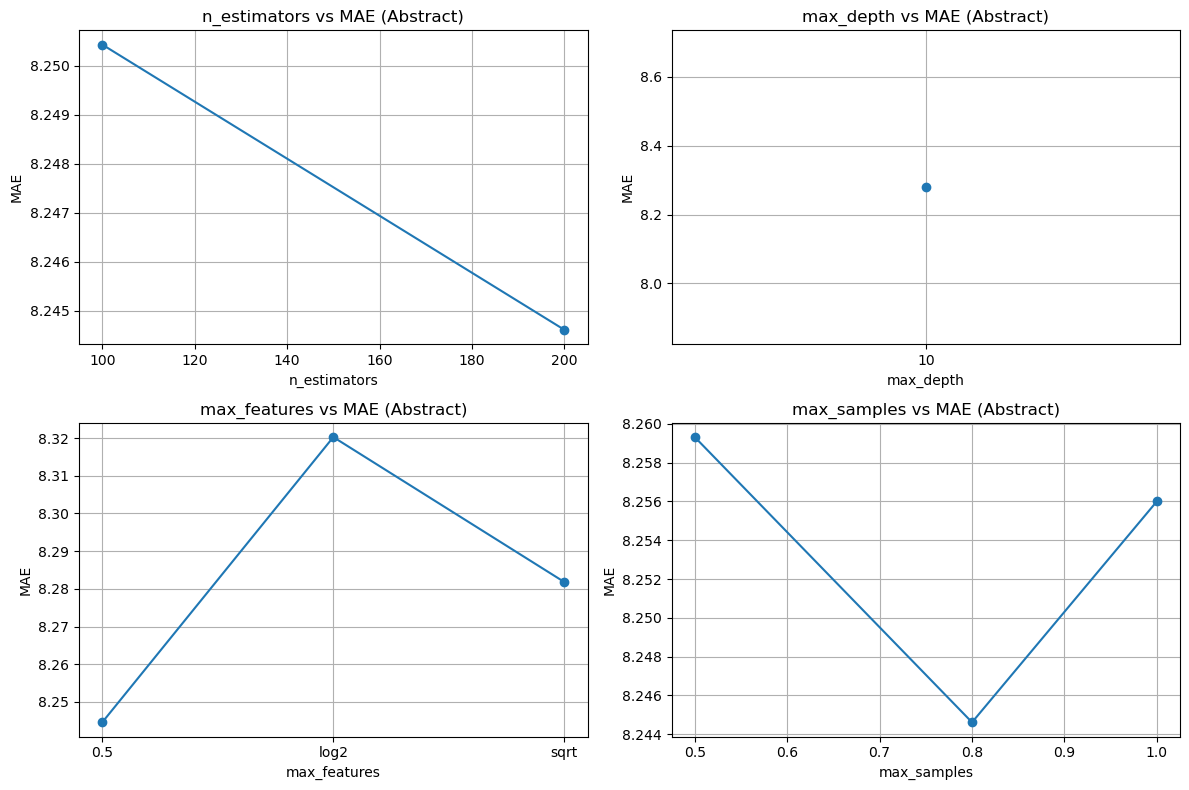

In [18]:
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X_tr = train_abs_emb
y_tr = y_train

print("Random Forest için Grid Search (Abstract temsili) yeniden başlatılıyor...")

grid_rf_full = GridSearchCV(
    estimator=rf_estimator,      
    param_grid=param_grid_rf,    
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid_rf_full.fit(X_tr, y_tr)


cv_df = pd.DataFrame(grid_rf_full.cv_results_)
cv_df["mean_MAE"] = -cv_df["mean_test_score"]

print("GridSearch sonuç tablosu (ilk satırlar):")
display(cv_df.head())




mae_by_estimators = (
    cv_df
    .groupby("param_n_estimators")["mean_MAE"]
    .min()
    .reset_index()
    .sort_values("param_n_estimators")
)

mae_by_depth = (
    cv_df
    .groupby("param_max_depth")["mean_MAE"]
    .min()
    .reset_index()
)

mae_by_depth["depth_sort"] = mae_by_depth["param_max_depth"].map(
    lambda v: 999 if v is None else int(v)
)
mae_by_depth = mae_by_depth.sort_values("depth_sort")

mae_by_features = (
    cv_df
    .groupby("param_max_features")["mean_MAE"]
    .min()
    .reset_index()
)

mae_by_features["feat_label"] = mae_by_features["param_max_features"].astype(str)

mae_by_samples = (
    cv_df
    .groupby("param_max_samples")["mean_MAE"]
    .min()
    .reset_index()
    .sort_values("param_max_samples")
)


fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(
    mae_by_estimators["param_n_estimators"],
    mae_by_estimators["mean_MAE"],
    marker="o"
)
axes[0, 0].set_title("n_estimators vs MAE (Abstract)")
axes[0, 0].set_xlabel("n_estimators")
axes[0, 0].set_ylabel("MAE")
axes[0, 0].grid(True)

x_labels_depth = mae_by_depth["param_max_depth"].astype(str).tolist()
x_pos_depth = np.arange(len(x_labels_depth))

axes[0, 1].plot(
    x_pos_depth,
    mae_by_depth["mean_MAE"],
    marker="o"
)
axes[0, 1].set_xticks(x_pos_depth)
axes[0, 1].set_xticklabels(x_labels_depth)
axes[0, 1].set_title("max_depth vs MAE (Abstract)")
axes[0, 1].set_xlabel("max_depth")
axes[0, 1].set_ylabel("MAE")
axes[0, 1].grid(True)

x_labels_feat = mae_by_features["feat_label"].tolist()
x_pos_feat = np.arange(len(x_labels_feat))

axes[1, 0].plot(
    x_pos_feat,
    mae_by_features["mean_MAE"],
    marker="o"
)
axes[1, 0].set_xticks(x_pos_feat)
axes[1, 0].set_xticklabels(x_labels_feat)
axes[1, 0].set_title("max_features vs MAE (Abstract)")
axes[1, 0].set_xlabel("max_features")
axes[1, 0].set_ylabel("MAE")
axes[1, 0].grid(True)

axes[1, 1].plot(
    mae_by_samples["param_max_samples"],
    mae_by_samples["mean_MAE"],
    marker="o"
)
axes[1, 1].set_title("max_samples vs MAE (Abstract)")
axes[1, 1].set_xlabel("max_samples")
axes[1, 1].set_ylabel("MAE")
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig("random_forest_hyperparameter_tuning_mae_abstract.png", dpi=300, bbox_inches="tight")
plt.show()


### 7.5 Bagging İçin Hiperparametre Optimizasyon Grafikleri

Bu bölümde, Bagging modelinin Abstract temsili
üzerinde yaptığı Grid Search sonuçlarını görselleştiriyorum.

Kullanılan hiperparametreler:
- `n_estimators`          Ağaç sayısı (50, 100)
- `max_samples`           Her ağaç için kullanılan örnek oranı (0.5, 1.0)
- `estimator__max_depth`  Taban karar ağacının maksimum derinliği (10, None)

Yöntem:
- Abstract temsili için `train_abs_emb` ve `y_train` kullanılarak
  Bagging modeli üzerinde GridSearchCV uygulanmıştır.
- Her hiperparametre değeri için çapraz doğrulama ortalama MAE değeri
  (`mean_MAE`) hesaplanmıştır.
- `n_estimators`, `max_samples` ve `estimator__max_depth` için
  MAE'nin nasıl değiştiğini gösteren üç ayrı çizgi grafiği çizilmiştir.

Bu grafikler sayesinde:
- Ağaç sayısını artırmanın hataya etkisi,
- Örnekleme oranını değiştirmenin etkisi,
- Sığ ağaçlar ile sınırsız derinlikli ağaçlar
  arasındaki fark
görsel olarak yorumlanabilmektedir.


Bagging için Grid Search (Abstract temsili) yeniden başlatılıyor...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Bagging GridSearch sonuç tablosu (ilk satırlar):


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_estimator__max_depth,param_max_samples,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,mean_MAE
0,121.333683,0.681597,0.884249,0.100071,10,0.5,50,"{'estimator__max_depth': 10, 'max_samples': 0....",-11.283149,-2.357926,-11.245221,-8.295432,4.198479,4,8.295432
1,229.844343,0.619048,1.309878,0.102303,10,0.5,100,"{'estimator__max_depth': 10, 'max_samples': 0....",-11.357272,-2.236273,-11.249901,-8.281149,4.274597,2,8.281149
2,197.995942,1.757521,0.732442,0.088537,10,1.0,50,"{'estimator__max_depth': 10, 'max_samples': 1....",-11.363408,-2.403284,-11.232262,-8.332985,4.193273,8,8.332985
3,336.856378,3.877406,0.959096,0.025415,10,1.0,100,"{'estimator__max_depth': 10, 'max_samples': 1....",-11.380034,-2.280979,-11.236178,-8.299064,4.255833,5,8.299064
4,154.626938,7.536590,0.741571,0.098704,None,0.5,50,"{'estimator__max_depth': None, 'max_samples': ...",-11.271562,-2.374045,-11.265713,-8.303773,4.192952,6,8.303773


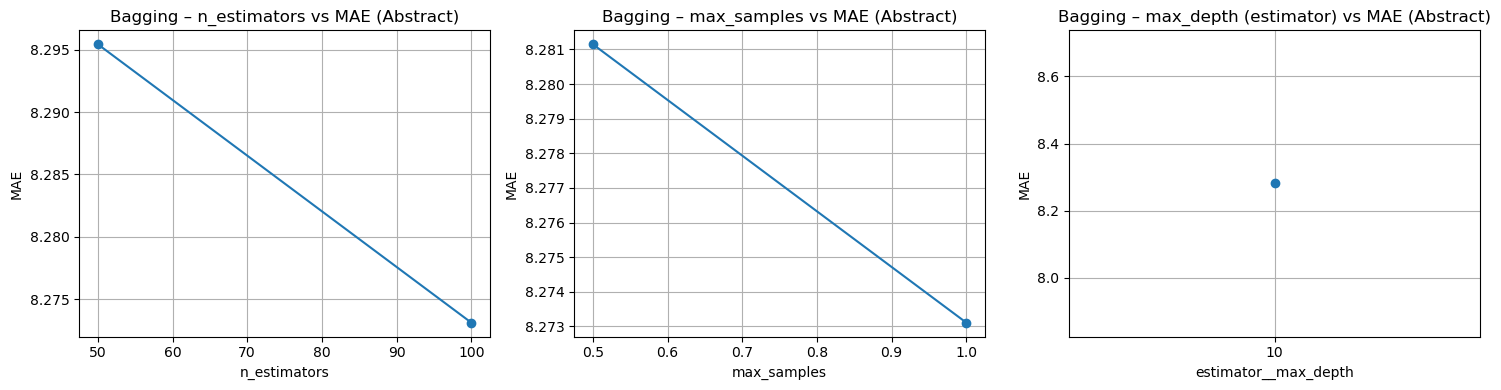

In [19]:
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


X_tr = train_abs_emb
y_tr = y_train

print("Bagging için Grid Search (Abstract temsili) yeniden başlatılıyor...")

grid_bag_abs = GridSearchCV(
    estimator=bagging_estimator,    
    param_grid=param_grid_bagging,   
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid_bag_abs.fit(X_tr, y_tr)

cv_bag = pd.DataFrame(grid_bag_abs.cv_results_)
cv_bag["mean_MAE"] = -cv_bag["mean_test_score"]

print("Bagging GridSearch sonuç tablosu (ilk satırlar):")
display(cv_bag.head())


mae_bag_estimators = (
    cv_bag
    .groupby("param_n_estimators")["mean_MAE"]
    .min()
    .reset_index()
    .sort_values("param_n_estimators")
)

mae_bag_samples = (
    cv_bag
    .groupby("param_max_samples")["mean_MAE"]
    .min()
    .reset_index()
    .sort_values("param_max_samples")
)

mae_bag_depth = (
    cv_bag
    .groupby("param_estimator__max_depth")["mean_MAE"]
    .min()
    .reset_index()
)

mae_bag_depth["depth_sort"] = mae_bag_depth["param_estimator__max_depth"].map(
    lambda v: 999 if v is None else int(v)
)
mae_bag_depth = mae_bag_depth.sort_values("depth_sort")


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(
    mae_bag_estimators["param_n_estimators"],
    mae_bag_estimators["mean_MAE"],
    marker="o"
)
axes[0].set_title("Bagging – n_estimators vs MAE (Abstract)")
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("MAE")
axes[0].grid(True)

axes[1].plot(
    mae_bag_samples["param_max_samples"],
    mae_bag_samples["mean_MAE"],
    marker="o"
)
axes[1].set_title("Bagging – max_samples vs MAE (Abstract)")
axes[1].set_xlabel("max_samples")
axes[1].set_ylabel("MAE")
axes[1].grid(True)

x_labels_depth_bag = mae_bag_depth["param_estimator__max_depth"].astype(str).tolist()
x_pos_depth_bag = np.arange(len(x_labels_depth_bag))

axes[2].plot(
    x_pos_depth_bag,
    mae_bag_depth["mean_MAE"],
    marker="o"
)
axes[2].set_xticks(x_pos_depth_bag)
axes[2].set_xticklabels(x_labels_depth_bag)
axes[2].set_title("Bagging – max_depth (estimator) vs MAE (Abstract)")
axes[2].set_xlabel("estimator__max_depth")
axes[2].set_ylabel("MAE")
axes[2].grid(True)

plt.tight_layout()
plt.savefig("bagging_hyperparameter_tuning_mae_abstract.png", dpi=300, bbox_inches="tight")
plt.show()


### 7.6 Random Subspace İçin Hiperparametre Optimizasyon Grafikleri

Bu bölümde, Random Subspace yaklaşımı için
Abstract temsili üzerinde yapılan Grid Search sonuçları görselleştirilmektedir.

Kullanılan hiperparametreler:
- `n_estimators`          Ağaç sayısı 
- `max_features`          Her ağaç için kullanılacak özellik oranı 
- `estimator__max_depth`  Taban karar ağacının maksimum derinliği 

Yöntem:
- `train_abs_emb` ve `y_train` kullanılarak Random Subspace modeli için GridSearchCV uygulanmıştır.
- Her hiperparametre değeri için çapraz doğrulama ortalama MAE değeri (`mean_MAE`)
  hesaplanmıştır.
- `n_estimators`, `max_features` ve `estimator__max_depth` için
  MAE'nin nasıl değiştiğini gösteren üç ayrı çizgi grafiği çizilmiştir.

Bu grafikler sayesinde:
- Ağaç sayısının etkisi,
- Özellik altkümesi oranının etkisi,
- Ağaç derinliğinin etkisi



Random Subspace için Grid Search (Abstract temsili) yeniden başlatılıyor...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Random Subspace GridSearch sonuç tablosu (ilk satırlar):


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_estimator__max_depth,param_max_features,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,mean_MAE
0,67.637993,0.872525,0.268561,0.014127,10,0.3,50,"{'estimator__max_depth': 10, 'max_features': 0...",-11.390976,-2.215342,-11.286343,-8.297554,4.300985,10,8.297554
1,132.349350,1.376898,0.472900,0.021054,10,0.3,100,"{'estimator__max_depth': 10, 'max_features': 0...",-11.415598,-2.122383,-11.309796,-8.282592,4.356140,7,8.282592
2,112.097381,1.806811,0.412667,0.006547,10,0.5,50,"{'estimator__max_depth': 10, 'max_features': 0...",-11.365948,-2.211561,-11.289164,-8.288891,4.297435,8,8.288891
3,211.092409,0.166386,0.718151,0.012402,10,0.5,100,"{'estimator__max_depth': 10, 'max_features': 0...",-11.396678,-2.145546,-11.283590,-8.275271,4.334616,5,8.275271
4,173.328110,2.686391,0.566528,0.005662,10,0.8,50,"{'estimator__max_depth': 10, 'max_features': 0...",-11.318194,-2.324275,-11.286560,-8.309676,4.232337,12,8.309676


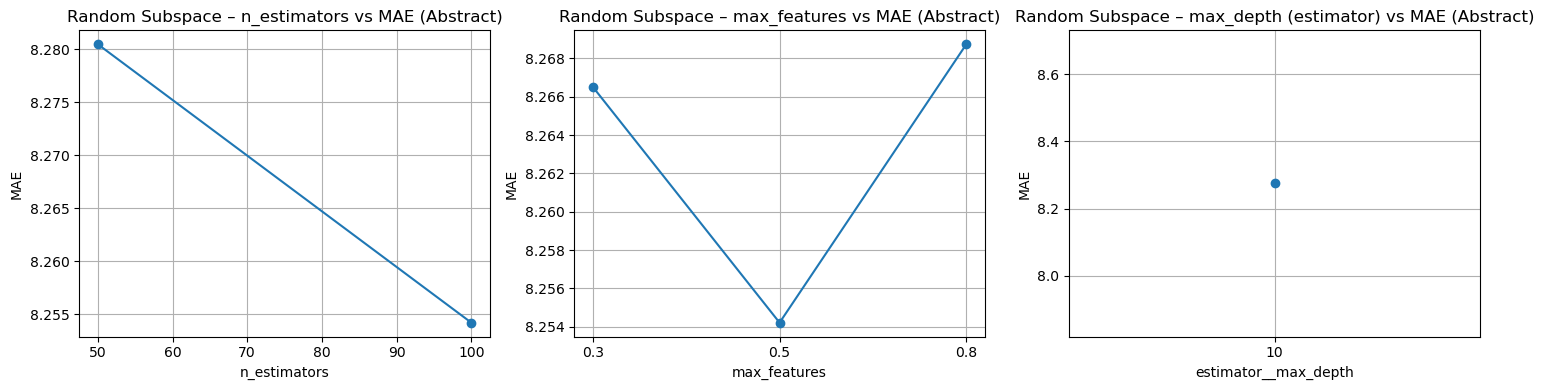

In [20]:
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


X_tr = train_abs_emb
y_tr = y_train

print("Random Subspace için Grid Search (Abstract temsili) yeniden başlatılıyor...")

grid_sub_abs = GridSearchCV(
    estimator=subspace_estimator,     
    param_grid=param_grid_subspace,   
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid_sub_abs.fit(X_tr, y_tr)

cv_sub = pd.DataFrame(grid_sub_abs.cv_results_)
cv_sub["mean_MAE"] = -cv_sub["mean_test_score"]

print("Random Subspace GridSearch sonuç tablosu (ilk satırlar):")
display(cv_sub.head())


mae_sub_estimators = (
    cv_sub
    .groupby("param_n_estimators")["mean_MAE"]
    .min()
    .reset_index()
    .sort_values("param_n_estimators")
)

mae_sub_features = (
    cv_sub
    .groupby("param_max_features")["mean_MAE"]
    .min()
    .reset_index()
)

mae_sub_features["feat_label"] = mae_sub_features["param_max_features"].astype(str)

mae_sub_depth = (
    cv_sub
    .groupby("param_estimator__max_depth")["mean_MAE"]
    .min()
    .reset_index()
)

mae_sub_depth["depth_sort"] = mae_sub_depth["param_estimator__max_depth"].map(
    lambda v: 999 if v is None else int(v)
)
mae_sub_depth = mae_sub_depth.sort_values("depth_sort")


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(
    mae_sub_estimators["param_n_estimators"],
    mae_sub_estimators["mean_MAE"],
    marker="o"
)
axes[0].set_title("Random Subspace – n_estimators vs MAE (Abstract)")
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("MAE")
axes[0].grid(True)

x_labels_feat_sub = mae_sub_features["feat_label"].tolist()
x_pos_feat_sub = np.arange(len(x_labels_feat_sub))

axes[1].plot(
    x_pos_feat_sub,
    mae_sub_features["mean_MAE"],
    marker="o"
)
axes[1].set_xticks(x_pos_feat_sub)
axes[1].set_xticklabels(x_labels_feat_sub)
axes[1].set_title("Random Subspace – max_features vs MAE (Abstract)")
axes[1].set_xlabel("max_features")
axes[1].set_ylabel("MAE")
axes[1].grid(True)

x_labels_depth_sub = mae_sub_depth["param_estimator__max_depth"].astype(str).tolist()
x_pos_depth_sub = np.arange(len(x_labels_depth_sub))

axes[2].plot(
    x_pos_depth_sub,
    mae_sub_depth["mean_MAE"],
    marker="o"
)
axes[2].set_xticks(x_pos_depth_sub)
axes[2].set_xticklabels(x_labels_depth_sub)
axes[2].set_title("Random Subspace – max_depth (estimator) vs MAE (Abstract)")
axes[2].set_xlabel("estimator__max_depth")
axes[2].set_ylabel("MAE")
axes[2].grid(True)

plt.tight_layout()
plt.savefig("random_subspace_hyperparameter_tuning_mae_abstract.png", dpi=300, bbox_inches="tight")
plt.show()


## 7.7 En İyi Hiperparametrelerle Scatter Grafikleri

Bu bölümde, GridSearchCV ile daha önce elde edilen **en iyi hiperparametreler** manuel olarak
`best_params_manual` sözlüğüne yazılmış ve her temsil–model ikilisi için
**gerçek yıl** ile **tahmin edilen yıl** arasındaki ilişki
saçılım grafiği ile görselleştirilmiştir.

Her kombinasyon için bir scatter grafiği çizilir:
   - X ekseni: Gerçek yıl  
   - Y ekseni: Tahmin edilen yıl  
   - Kırmızı kesikli çizgi: Mükemmel tahmin hattı (y = x)

Bu görsel, modellerin yılları ne kadar doğru tahmin ettiğini ve
tahminlerin yıl bazında ne yönde sapma yaptığını hızlıca karşılaştırmayı sağlar.


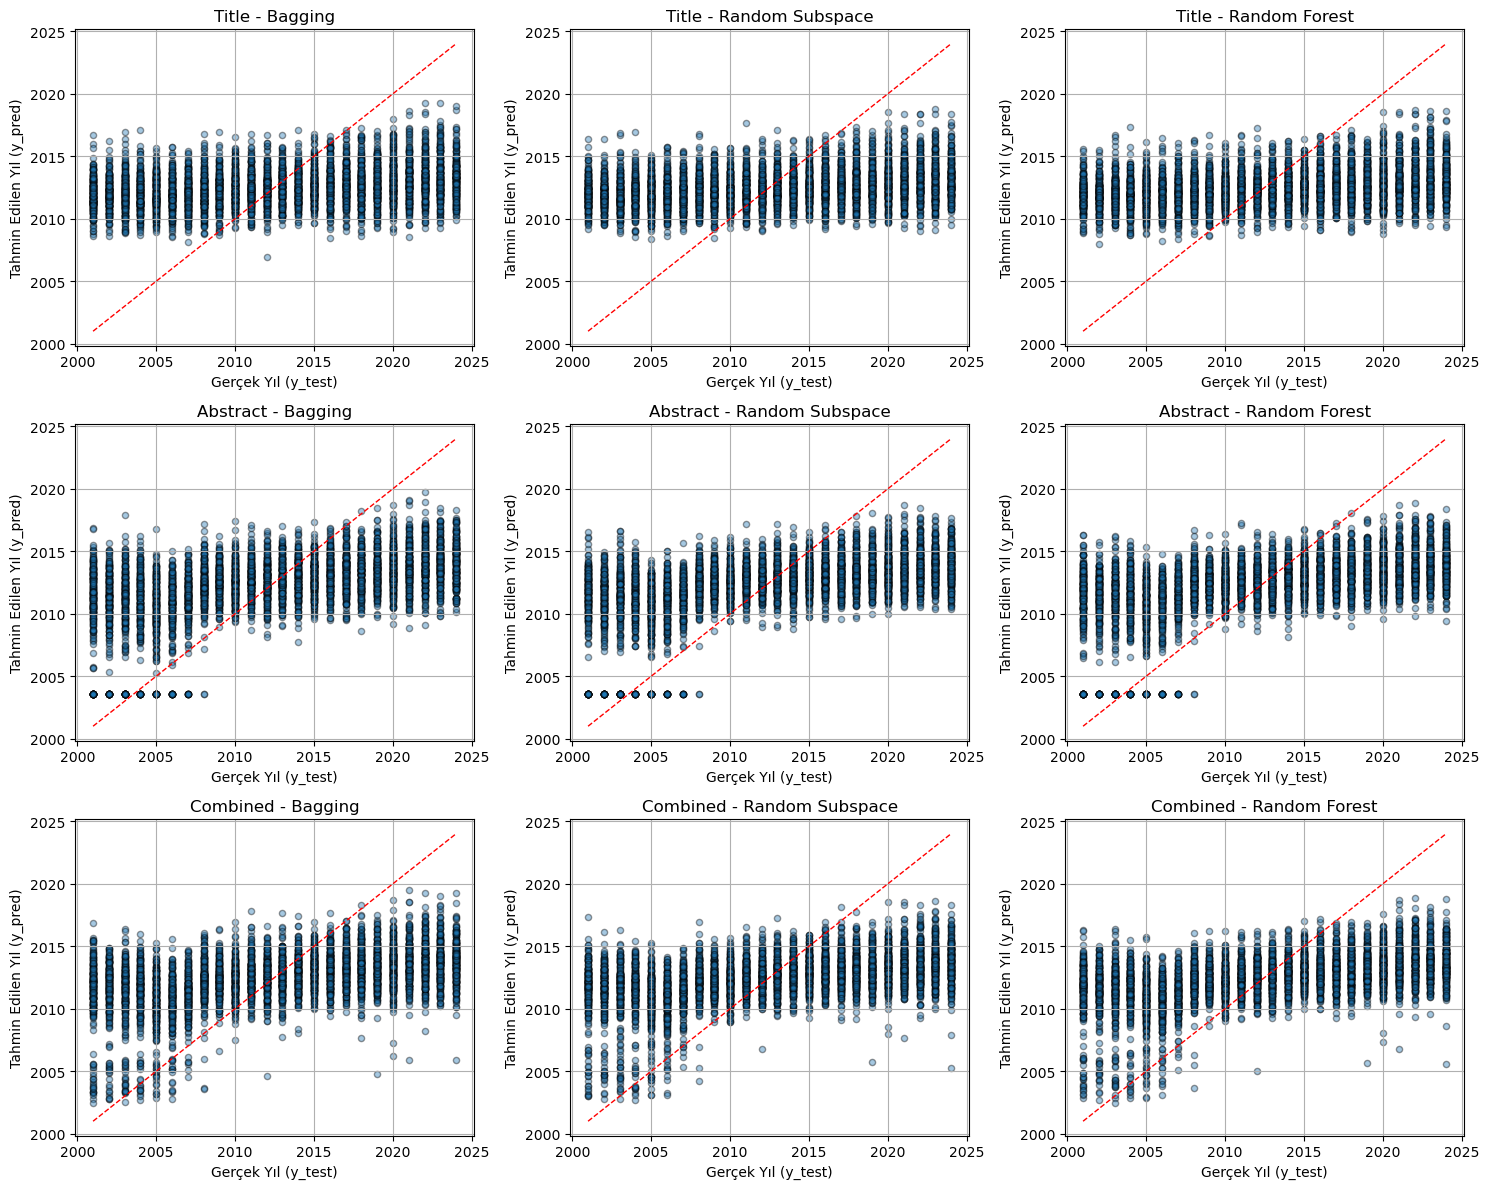

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

best_params_manual = {

    # TITLE
    ("Title", "Bagging"): {
        "n_estimators": 100,
        "max_samples": 1.0,
        "estimator_max_depth": None,
    },
    ("Title", "Random Subspace"): {
        "n_estimators": 100,
        "max_features": 0.5,
        "estimator_max_depth": 10,
    },
    ("Title", "Random Forest"): {
        "n_estimators": 200,
        "max_features": 0.5,
        "max_samples": 0.8,
        "max_depth": None,
    },

    # ABSTRACT
    ("Abstract", "Bagging"): {
        "n_estimators": 100,
        "max_samples": 1.0,
        "estimator_max_depth": None,
    },
    ("Abstract", "Random Subspace"): {
        "n_estimators": 100,
        "max_features": 0.5,
        "estimator_max_depth": None,
    },
    ("Abstract", "Random Forest"): {
        "n_estimators": 200,
        "max_features": 0.5,
        "max_samples": 0.8,
        "max_depth": None,
    },

    # COMBINED
    ("Combined", "Bagging"): {
        "n_estimators": 100,
        "max_samples": 1.0,
        "estimator_max_depth": None,
    },
    ("Combined", "Random Subspace"): {
        "n_estimators": 100,
        "max_features": 0.5,
        "estimator_max_depth": None,
    },
    ("Combined", "Random Forest"): {
        "n_estimators": 200,
        "max_features": 0.5,
        "max_samples": 1.0,
        "max_depth": None,
    },
}

rep_to_data = {
    "Title":    (train_title_emb, test_title_emb),
    "Abstract": (train_abs_emb,   test_abs_emb),
    "Combined": (train_comb_emb,  test_comb_emb),
}

models = ["Bagging", "Random Subspace", "Random Forest"]
reps = ["Title", "Abstract", "Combined"]

fig, axes = plt.subplots(len(reps), len(models), figsize=(15, 12))

for i, rep in enumerate(reps):
    X_tr, X_te = rep_to_data[rep]

    for j, model_name in enumerate(models):
        ax = axes[i, j]

        cfg = best_params_manual.get((rep, model_name), None)
        if cfg is None:
            ax.set_title(f"{rep} - {model_name}\n(param yok)")
            ax.axis("off")
            continue

        if model_name == "Bagging":
            base_depth = cfg.get("estimator_max_depth", None)
            base_tree = DecisionTreeRegressor(
                max_depth=base_depth,
                random_state=42
            )
            model = BaggingRegressor(
                estimator=base_tree,
                n_estimators=cfg.get("n_estimators", 50),
                max_samples=cfg.get("max_samples", 1.0),
                random_state=42
            )

        elif model_name == "Random Subspace":
            base_depth = cfg.get("estimator_max_depth", None)
            base_tree = DecisionTreeRegressor(
                max_depth=base_depth,
                random_state=42
            )
            model = BaggingRegressor(
                estimator=base_tree,
                n_estimators=cfg.get("n_estimators", 50),
                max_features=cfg.get("max_features", 0.5),
                random_state=42
            )

        elif model_name == "Random Forest":
            model = RandomForestRegressor(
                n_estimators=cfg.get("n_estimators", 100),
                max_features=cfg.get("max_features", "sqrt"),
                max_samples=cfg.get("max_samples", 1.0),
                max_depth=cfg.get("max_depth", None),
                random_state=42,
                bootstrap=True
            )
        else:
            ax.set_title(f"{rep} - {model_name}\n(desteklenmiyor)")
            ax.axis("off")
            continue

        model.fit(X_tr, y_train)

        y_pred = model.predict(X_te)

        ax.scatter(y_test, y_pred, alpha=0.4, edgecolor="k", s=20)

        min_year = min(y_test.min(), y_pred.min())
        max_year = max(y_test.max(), y_pred.max())
        ax.plot([min_year, max_year], [min_year, max_year], "r--", linewidth=1)

        ax.set_title(f"{rep} - {model_name}")
        ax.set_xlabel("Gerçek Yıl (y_test)")
        ax.set_ylabel("Tahmin Edilen Yıl (y_pred)")
        ax.grid(True)

plt.tight_layout()
plt.savefig("year_prediction_scatter_all_models_all_representations.png", dpi=300, bbox_inches="tight")
plt.show()
